In [1]:
from loadPressureData import loadPressureData
from detide import detide
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Spectral method review
Estimate wave energy with Welch-style sliding spectra (because there is a function for it that is easy to use):

1. Segment the high-passed pressure into overlapping windows (~30 min with 50% overlap).
2. Apply a Hann taper and compute the FFT.
3. Convert pressure spectra $S_{pp}(f)$ to surface elevation spectra $S_{\eta\eta}(f)$ using the linear transfer function from Falk's *Notes on 
Nearshore Physical Oceanography (Chapter 8)*
$$S_{\eta\eta}(f) = \left[\frac{\cosh(k(f) h)}{\rho g}\right]^2 S_{pp}(f),$$

where the wavenumber $k$ satisfies the dispersion relation $\omega^2 = g k \tanh(k h)$.

4. Integrate $S_{\eta\eta}$ to obtain significant wave height $H_s = 4\sqrt{m_0}$ over different frequency bands (sea/swell and infragravity), and record the sea/swell peak period $T_p = 1 / f_p$.


Falk's notes defines the sea-swell frequency band as $0.05<f<0.03 Hz$

The purpose of this notebook is to do exploratory analysis on the pressure sensor data at mokuleia. This includes testing of scripts, functions, and memory tests. 6969696969 666 hrfeaik satannnnnn lucilfrer wioo rise

In [2]:
## ---------LOAD DERTER---------- ##
dat1 = loadPressureData('data/MoA18411.mat') 
S1 = pd.DataFrame().assign(
    time=dat1.time,
    pressure=dat1.pressure_pa,
    depth=dat1.depth_m,
).set_index('time')

S1= (
    S1.interpolate(method="time", limit_direction="both")
      .ffill()
      .bfill()
)

# load two bursts/records for sensor 4
dat4 = loadPressureData('data/MoA48411.mat')
dat4b = loadPressureData('data/MoB48411.mat')
S4a = pd.DataFrame().assign(
    time=dat4.time,
    pressure=dat4.pressure_pa,
    depth=dat4.depth_m,
).set_index('time')
S4b = pd.DataFrame().assign(
    time=dat4b.time,
    pressure=dat4b.pressure_pa,
    depth=dat4b.depth_m,
).set_index('time')

# merging 4a and 4b (stack in time)
S4 = pd.concat([S4a, S4b], axis=0).sort_index()
S4.shape, S1.shape


((6259738, 2), (7948780, 2))

#### Autospectra

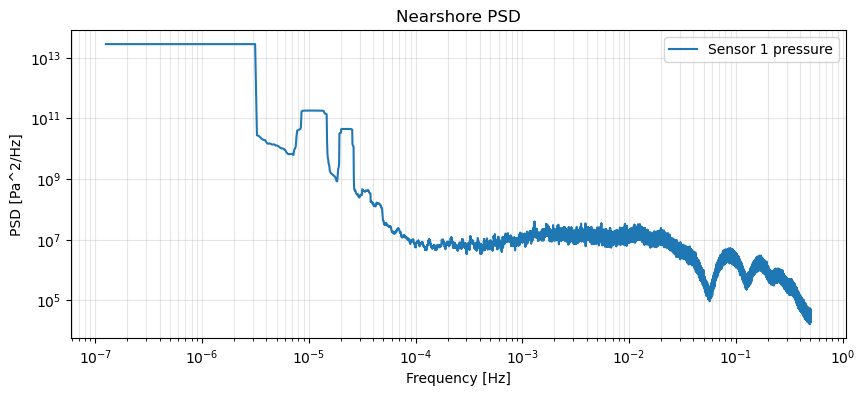

In [3]:
## -------------- Nearshore Autospectra ---------------- ##
N = len(S1)
f = np.fft.rfftfreq(N, d=1)
bin_avg = 50 #smooting window 
fftS1 = np.fft.rfft(S1.pressure.values)
psdS1 = (1/(N)) * np.abs(fftS1)**2
psdS1_avg = np.convolve(psdS1, np.ones(bin_avg)/bin_avg, mode='same')  # simple moving average

plt.figure(figsize=(10, 4))
plt.loglog(f[1:], psdS1_avg[1:], label="Sensor 1 pressure")
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [Pa^2/Hz]")
plt.title("Nearshore PSD")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()


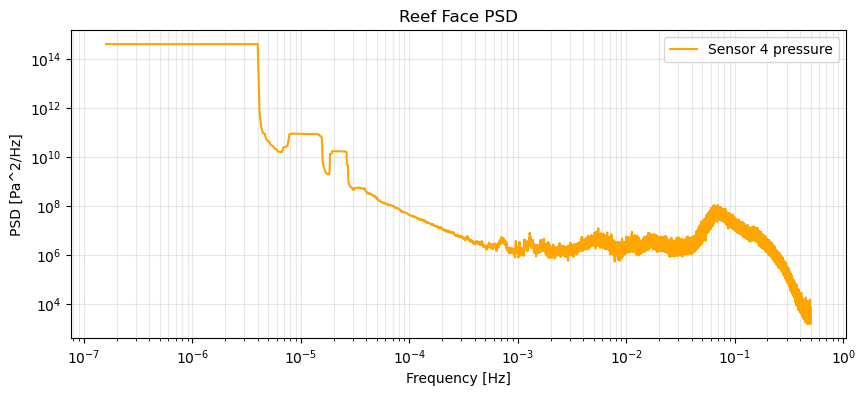

In [4]:
## -------------- Reef Face Autospectra ---------------- ##
N = len(S4)
f = np.fft.rfftfreq(N, d=1)
bin_avg = 50 #smooting window 
fftS4 = np.fft.rfft(S4.pressure.values)
psdS4 = (1/(N)) * np.abs(fftS4)**2
psdS4_avg = np.convolve(psdS4, np.ones(bin_avg)/bin_avg, mode='same')  # simple moving average

plt.figure(figsize=(10, 4))
plt.loglog(f[1:], psdS4_avg[1:], label="Sensor 4 pressure", color='orange')
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [Pa^2/Hz]")
plt.title("Reef Face PSD")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

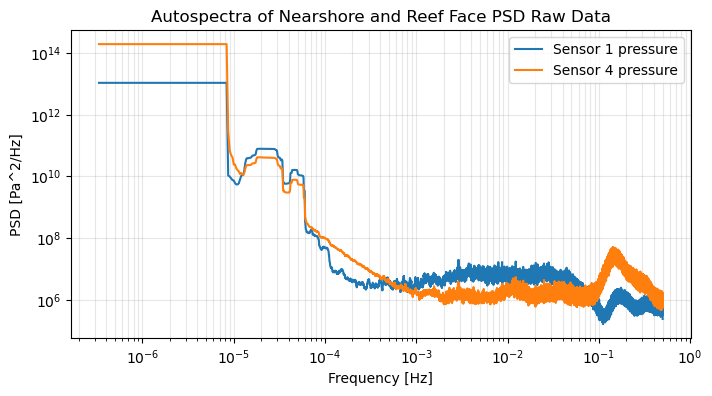

In [5]:
idx = S1.index.intersection(S4.index)
S1auto = S1.loc[idx]
S4auto = S4.loc[idx]

N = len(idx)
f = np.fft.rfftfreq(N, d=1)

fftS1 = np.fft.rfft(S1auto.pressure.values)
fftS4 = np.fft.rfft(S4auto.pressure.values)


psdS1_join = np.abs(fftS1)**2 / N
psdS4_join = np.abs(fftS4)**2 / N

psdS1_join_avg = np.convolve(psdS1_join, np.ones(bin_avg)/bin_avg, mode='same')
psdS4_join_avg = np.convolve(psdS4_join, np.ones(bin_avg)/bin_avg, mode='same')

plt.figure(figsize=(8, 4))
plt.loglog(f[1:],psdS1_join_avg[1:], label="Sensor 1 pressure")
plt.loglog(f[1:], psdS4_join_avg[1:], label="Sensor 4 pressure")
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [Pa^2/Hz]")
plt.title("Autospectra of Nearshore and Reef Face PSD Raw Data")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()





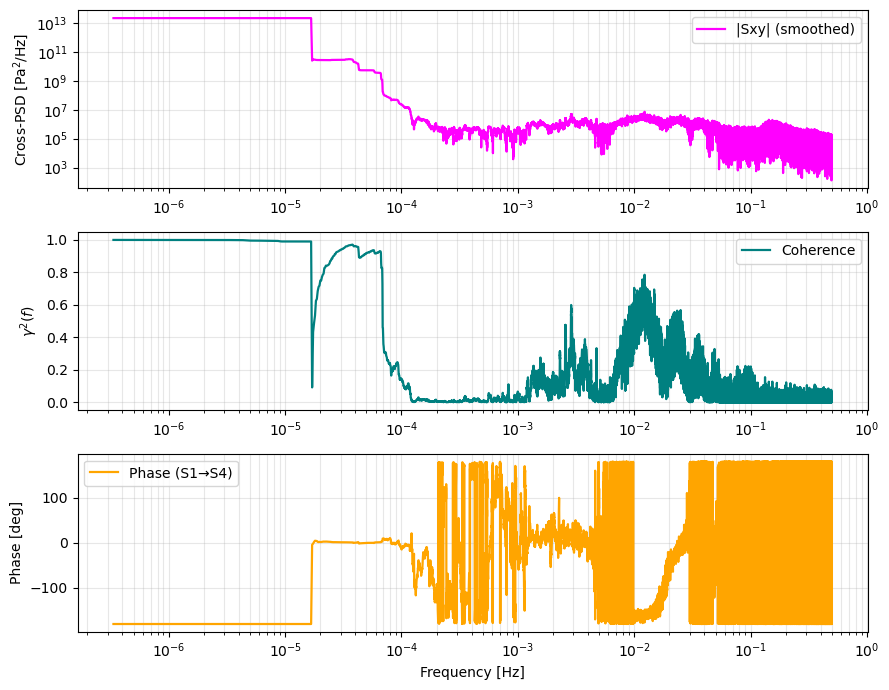

In [11]:
## -------------- Cross Spectra Analysis ---------------- ##
# --- align series ---
idx = S1.index.intersection(S4.index)
x = S1.loc[idx].pressure.values.astype(float)
y = S4.loc[idx].pressure.values.astype(float)

N = len(idx); fs = 1.0
f = np.fft.rfftfreq(N, d=1/fs)

# --- FFTs ---
X = np.fft.rfft(x)
Y = np.fft.rfft(y)

# --- auto & cross spectra (periodogram-style) ---
Sxx = (np.abs(X)**2) / N
Syy = (np.abs(Y)**2) / N
Sxy = (np.conj(X) * Y) / N   # cross-spectrum (complex)

# window smoothing
bin_avg = 101  # adjust 
k = np.ones(bin_avg)/bin_avg
Sxx_s = np.convolve(Sxx, k, mode='same')
Syy_s = np.convolve(Syy, k, mode='same')
Sxy_s = np.convolve(Sxy.real, k, mode='same') + 1j*np.convolve(Sxy.imag, k, mode='same')

# --- coherence & phase ---
coh = np.abs(Sxy_s)**2 / (Sxx_s * Syy_s)
phase_deg = np.degrees(np.angle(Sxy_s))      # S1 leads S4 if phase < 0 with this definition

# --- plots ---
m = f > 0  # drop f=0 for logs
plt.figure(figsize=(9,7))

# cross-spectrum magnitude
plt.subplot(3,1,1)
plt.loglog(f[m], np.abs(Sxy_s[m]), lw=1.6, label='|Sxy| (smoothed)', color='magenta')
plt.ylabel('Cross-PSD [Pa$^2$/Hz]')
plt.grid(True, which='both', alpha=0.3); plt.legend()

# coherence
plt.subplot(3,1,2)
plt.semilogx(f[m], np.clip(coh[m], 0, 1), lw=1.6, label='Coherence', color = "teal")
plt.ylabel(r'$\gamma^2(f)$'); plt.grid(True, which='both', alpha=0.3); plt.legend()

# phase
plt.subplot(3,1,3)
plt.semilogx(f[m], phase_deg[m], lw=1.6, label='Phase (S1→S4)', color='orange')
plt.xlabel('Frequency [Hz]'); plt.ylabel('Phase [deg]')
plt.grid(True, which='both', alpha=0.3); plt.legend()

plt.tight_layout(); plt.show()
